# 📗 기초 수학 종합 과제
## Private LLM 사내 문서 검색·압축·Attention 진단

여러분은 사내 지식 검색 Private LLM의 **PoC 검증 담당 AI 엔지니어**입니다. 서비스 오픈 전 아래 항목을 코드와 실행 결과로 확인해야 합니다.

1. 질문과 관련된 문서가 Vector Search 상위에 노출되는지 확인합니다.
2. 정보 보존율 90% 이상을 유지하면서 임베딩 차원과 저장량을 줄일 수 있는지 판단합니다.
3. Causal Attention에서 미래 토큰 누수가 없는지 진단합니다.
4. Gradient 계산과 한 번의 SGD 업데이트가 Loss를 실제로 줄이는지 확인합니다.

```text
문서 특징 → Projection → Cosine Search
         → PCA/SVD 압축
         → Causal Attention → Cross Entropy
         → Autograd → Gradient Descent
```

- 외부 데이터 다운로드, 유료 API, GPU를 사용하지 않습니다.
- 위에서 아래로 순서대로 실행하세요.
- 공식 구현 성취도는 문제 1~3의 15점이며, 문제 4는 별도 추가 종합 평가 5점입니다.
- 선택 심화 M1~M4는 점수 필수 조건이 아닙니다.
- 각 문제의 TODO를 완성한 뒤 자동 검증 셀에서 `PASS`를 확인하세요.
- 마지막에는 실행 결과를 근거로 **엔지니어링 요약 보고서**를 작성하세요.


## 0. 실행 환경·제출·채점 안내

- 권장 환경: Google Colab 무료 CPU 런타임
- 핵심 dtype: `float64`
- **공식 구현 성취도:** 문제 1-3을 각각 1-5점으로 평가하여 총 15점입니다.
- **추가 종합 평가:** 문제 4를 0~5점으로 별도 평가합니다.
- **전체 합계:** 20점입니다.
- 선택 심화 M1~M4는 5점을 받기 위한 필수 조건이 아니며 점수에 직접 반영하지 않습니다.
- 선택 심화를 수행하지 않을 때는 `RUN_M*_CHALLENGE = False`로 유지하세요.
- 문제 4는 **Checkpoint A → B → C** 순서로 진행하세요.
- 제출 전 `런타임 → 세션 다시 시작 → 모두 실행`을 수행하세요.

### 공식 구현 성취도 매핑

| 문제 | 공식 구현 평가 항목 | 배점 |
|---|---|---:|
| 문제 1 | 벡터 ⋅ 행렬 연산을 Numpy로 구현하고 결과를 검증할 수 있다 | 5점 |
| 문제 2 | 고유값 분해를 통해 PCA를 구현하고, 주성분 개수에 따른 분산 설명력 변화를 분석하여 적절한 차원 수를 결정할 수 있다 | 5점 |
| 문제 3 | SVD를 구현하여 행렬을 저차원으로 근사하고, 압축률과 정보 손실 간의 관계를 비교·해석할 수 있다 | 5점 |
| 문제 4 | Attention·Cross Entropy·Gradient를 연결하는 추가 종합 평가 | 5점 |

### 필수 산출물

1. 공식 성취도 문제 1~3 자동 검증 `PASS`
2. 추가 종합 문제 4 Checkpoint A·B·C `PASS`
3. 표와 그래프가 포함된 실행 결과
4. PCA·SVD 의사결정 메모
5. Attention 누수·위치별 NLL·업데이트 전후 Loss 진단
6. 마지막의 최종 엔지니어링 요약 보고서


In [104]:
import sys
import platform
import hashlib

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import torch
import torch.nn.functional as F

np.set_printoptions(precision=6, suppress=True)
torch.set_printoptions(precision=6)


def result_signature(values, decimals=10):
    """자동 검증용 숫자 배열 서명을 만듭니다. 정답 숫자를 직접 노출하지 않습니다."""
    array = np.asarray(values, dtype=np.float64)
    rounded = np.round(array, decimals=decimals)
    return hashlib.sha256(rounded.tobytes()).hexdigest()


def text_signature(values):
    """문자열 목록의 순서까지 포함한 자동 검증용 서명을 만듭니다."""
    text = "|".join(map(str, values))
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)
print("PyTorch:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())


Python: 3.14.4
Platform: Linux-6.18.33.2-microsoft-standard-WSL2-x86_64-with-glibc2.43
NumPy: 2.5.2
pandas: 3.0.5
Matplotlib: 3.11.1
scikit-learn: 1.9.0
PyTorch: 2.13.0+cu130
CUDA 사용 가능: True


## 0-1. 제공 데이터

`document_features`는 실제 기업 데이터가 아니라 학습을 위해 직접 구성한 고정 숫자입니다. 각 열은 보안, 인사, 인프라, 비용, 절차, 정책, 문제 해결, 계정 요청 신호를 나타냅니다.

한 문서 벡터의 크기를 의도적으로 크게 설정해, 정규화하지 않은 내적과 Cosine Similarity의 차이를 관찰할 수 있도록 했습니다.


In [105]:
document_titles = [
    "VPN 접속 오류 해결",
    "비밀번호 재설정 절차",
    "계정 잠금 해제 가이드",
    "연차 신청 방법",
    "복리후생 제도 안내",
    "재택근무 보안 정책",
    "GCP GPU VM 생성",
    "Kubernetes 배포 체크리스트",
    "서비스 장애 대응 절차",
    "법인카드 정산 규정",
    "출장비 지급 기준",
    "구매 요청 승인 절차",
]

feature_names = [
    "보안·접근",
    "인사",
    "인프라",
    "비용",
    "절차",
    "정책",
    "문제해결",
    "계정·요청",
]

document_features = np.array([
    [0.80, 0.00, 0.60, 0.00, 0.70, 0.20, 0.90, 0.50],
    [1.00, 0.00, 0.10, 0.00, 1.00, 0.40, 0.70, 0.90],
    [0.95, 0.00, 0.05, 0.00, 0.90, 0.30, 0.85, 1.00],
    [0.10, 1.00, 0.00, 0.00, 0.90, 0.30, 0.10, 0.70],
    [0.00, 1.00, 0.00, 0.10, 0.50, 0.80, 0.00, 0.20],
    [0.70, 0.70, 0.20, 0.00, 0.40, 1.00, 0.20, 0.30],
    [0.10, 0.00, 1.00, 0.00, 0.80, 0.20, 0.50, 0.40],
    # 크기가 큰 문서 벡터: 정규화하지 않은 내적이 norm의 영향을 받는 사례입니다.
    [0.40, 0.00, 2.00, 0.00, 1.80, 0.80, 0.80, 0.40],
    [0.50, 0.00, 0.80, 0.00, 0.70, 0.30, 1.00, 0.20],
    [0.00, 0.10, 0.00, 1.00, 0.60, 0.90, 0.10, 0.30],
    [0.00, 0.30, 0.00, 1.00, 0.50, 0.80, 0.00, 0.20],
    [0.10, 0.20, 0.10, 0.80, 0.90, 0.70, 0.10, 0.80],
], dtype=np.float64)

projection_matrix = np.array([
    [0.8, 0.0, 0.1, 0.0, 0.2, 0.2],
    [0.0, 0.9, 0.0, 0.0, 0.1, 0.3],
    [0.1, 0.0, 0.9, 0.0, 0.2, 0.1],
    [0.0, 0.0, 0.0, 0.9, 0.1, 0.2],
    [0.2, 0.1, 0.1, 0.1, 0.7, 0.2],
    [0.2, 0.2, 0.1, 0.2, 0.1, 0.8],
    [0.3, 0.0, 0.3, 0.0, 0.8, 0.1],
    [0.5, 0.1, 0.1, 0.2, 0.3, 0.2],
], dtype=np.float64)

projection_bias = np.array([0.05, 0.02, 0.03, 0.01, 0.04, 0.02], dtype=np.float64)

query_text = "비밀번호를 잊었을 때 계정을 다시 사용하는 방법"
query_features = np.array([1.00, 0.00, 0.00, 0.00, 1.00, 0.20, 0.80, 0.95], dtype=np.float64)

print("문서 특징 Shape:", document_features.shape)
print("Projection 행렬 Shape:", projection_matrix.shape)
print("Bias Shape:", projection_bias.shape)
print("Query 특징 Shape:", query_features.shape)


문서 특징 Shape: (12, 8)
Projection 행렬 Shape: (8, 6)
Bias Shape: (6,)
Query 특징 Shape: (8,)


# 문제 1. 사내 문서 임베딩과 Cosine Vector Search — 공식 구현 성취도 5점

> **공식 구현 평가 항목:** 벡터 ⋅ 행렬 연산을 Numpy로 구현하고 결과를 검증할 수 있다.

## 채점 기준

| 점수 | 기준 |
|---:|---|
| 5점 | 정확한 구현과 결과 검증 + 브로드캐스팅/차원 처리와 수식 대응 근거까지 제시 |
| 4점 | 요구된 벡터·행렬 연산을 구현하고 결과를 검증 |
| 3점 | 연산은 되나 일부 검증 누락 또는 차원 처리 부정확 |
| 2점 | Shape 불일치 등 연산 오류로 결과가 잘못됨 |
| 1점 | 핵심 연산 구현이 되지 않아 실행 불가 |

## 실무 배경

사용자가 “비밀번호를 잊었을 때 계정을 다시 사용하는 방법”을 질문했습니다. 문서 특징을 작은 임베딩 공간으로 Projection한 뒤, Query와 가까운 문서를 Cosine Similarity로 검색하세요.

## 필수 구현

1. `(12, 8) @ (8, 6) + (6,)`으로 문서 임베딩 `(12, 6)`을 만드세요.
2. 같은 Projection을 Query `(8,)`에 적용해 Query 임베딩 `(6,)`을 만드세요.
3. 첫 문서·첫 출력 원소를 개별 내적으로 다시 계산해 행렬곱과 비교하세요.
4. 문서의 **각 행**과 Query를 각각 L2 정규화하세요.
5. 정규화된 내적으로 Cosine Similarity 12개를 계산하세요.
6. 점수가 큰 순서대로 Top-3 index·제목·점수를 `top3_table`로 정리하세요.

> 막혔다면 `axis=1`, `keepdims=True`, `np.argsort(...)[::-1]`을 먼저 확인하세요.

## 제출 결과

- 문서·Query 임베딩 Shape
- 정규화 전후 norm
- Cosine Top-3 표
- `문제 1 자동 검증: PASS`
- 브로드캐스팅·차원 처리·수식 대응 근거
- 검색 결과가 질문 의도와 맞는지에 대한 엔지니어링 해석


In [106]:
def l2_normalize_rows(matrix, eps=1e-12):
    """행별 L2 norm을 1로 맞추는 함수를 완성하세요."""
    # TODO: axis=1, keepdims=True를 사용하세요.
    return matrix / np.maximum(eps, np.linalg.norm(matrix, axis=1, keepdims=True))


def l2_normalize_vector(vector, eps=1e-12):
    """1차원 벡터의 L2 norm을 1로 맞추는 함수를 완성하세요."""
    return vector / np.maximum(eps, np.linalg.norm(vector))


document_embeddings = document_features @ projection_matrix + projection_bias   # TODO: document_features @ projection_matrix + projection_bias
query_embedding = query_features @ projection_matrix + projection_bias        # TODO: query_features에 같은 Projection 적용
first_component_by_dot = document_features[0] @ projection_matrix[:, 0] + projection_bias[0] # TODO: 첫 문서·첫 출력 차원의 개별 내적 + bias

print(f"query_features.shape: {query_features.shape}")
print(f"projection_matrix.shape: {projection_matrix.shape}")
print((query_features @ projection_matrix).shape)
print(f"query_embedding.shape: {query_embedding.shape}")

normalized_documents = l2_normalize_rows(document_embeddings)   # TODO
normalized_query = l2_normalize_vector(query_embedding)       # TODO
cosine_scores = (normalized_documents @ normalized_query)          # TODO
top3_indices = np.argsort(cosine_scores)[::-1][:3]       # TODO
top3_titles = np.asarray(document_titles)[top3_indices]             # TODO
top3_table = pd.DataFrame({
    "rank": [1, 2, 3],
    "index": top3_indices,
    "title": top3_titles,
    "cosine_similarity": cosine_scores[top3_indices],
    "embedding_norm_before": np.linalg.norm(document_embeddings, axis=1)[top3_indices]
})              # TODO: DataFrame으로 rank/index/title/score 정리

print(top3_table)

query_features.shape: (8,)
projection_matrix.shape: (8, 6)
(6,)
query_embedding.shape: (6,)
   rank  index         title  cosine_similarity  embedding_norm_before
0     1      2  계정 잠금 해제 가이드           0.999528               2.876704
1     2      1   비밀번호 재설정 절차           0.998024               2.871498
2     3      0  VPN 접속 오류 해결           0.975510               2.594186


In [107]:
problem_1_values = {
    "document_embeddings": document_embeddings,
    "query_embedding": query_embedding,
    "first_component_by_dot": first_component_by_dot,
    "normalized_documents": normalized_documents,
    "normalized_query": normalized_query,
    "cosine_scores": cosine_scores,
    "top3_indices": top3_indices,
    "top3_titles": top3_titles,
    "top3_table": top3_table,
}

missing_problem_1 = [name for name, value in problem_1_values.items() if value is None]

if missing_problem_1:
    print("문제 1 미완성:", missing_problem_1)
else:
    assert document_embeddings.shape == (12, 6), "문서 Projection Shape을 확인하세요."
    assert query_embedding.shape == (6,), "Query Projection Shape을 확인하세요."
    assert np.allclose(document_embeddings[0, 0], first_component_by_dot), "개별 내적 검증이 다릅니다."
    assert np.allclose(np.linalg.norm(normalized_documents, axis=1), 1.0), "문서의 행별 L2 정규화를 확인하세요."
    assert np.allclose(np.linalg.norm(normalized_query), 1.0), "Query L2 정규화를 확인하세요."
    assert cosine_scores.shape == (12,), "Cosine Score Shape을 확인하세요."
    assert np.all((-1.0 - 1e-12 <= cosine_scores) & (cosine_scores <= 1.0 + 1e-12)), "Cosine 범위를 확인하세요."
    assert list(top3_table.columns) == ["rank", "index", "title", "cosine_similarity", "embedding_norm_before"], "Top-3 표의 열을 확인하세요."
    assert result_signature(cosine_scores) == "36925b6756f42cb3cefa14061a30dd470d9b5b192ab12c3eccefb15b4013f21c", "Projection·정규화·Cosine 계산 순서를 확인하세요."
    assert result_signature(top3_indices) == "89cc6d9f671bcf9533fdf2720bc94179d00cf2f300639b976376bbb533abfb5e", "Top-3 정렬 순서를 확인하세요."
    assert text_signature(top3_titles) == "cfe4b5ad23a94ace112c6d30ebeaa1da495199e784bc69677ee68352fa2180c2", "Top-3 제목과 index 연결을 확인하세요."
    print("문제 1 자동 검증: PASS")


문제 1 자동 검증: PASS


### 문제 1 — 문서 검색 진단 보고

1. Bias Broadcasting의 Shape 근거:

    document_embeddings = document_features @ projection_matrix + projection_bias  

    위 식에서는 document_features @ projection_matrix 의 결과의 shape가 (12, 6) 이고, projection_bias의 shape는 (6,) 인데, 브로드캐스팅은 오른쪽 숫자부터 확인하는데, 6은 일치하므로 넘어가고, bias쪽 차원이 안맞으므로, 계산시 임의로 1이 있다고 가정하여 (1, 6)이 되고, 앞선 shape와 계산을 위해 맞춰주게 되어 12가 된다.

2. 내적과 Cosine Similarity의 norm 영향 차이:
    norm으로 정규화 하지 않은 내적값에서 코사인 유사도를 구하기 위해서는, 내적을 위해 연산한 각 A, B에 대한 L2 norm의곱을 나눠줘야 하지만, 이미 각 벡터가 자신의 norm으로 나눠 길이를 1로 했기에 그 과정을 생략해도 된다.

3. 실제 Cosine Top-3: 
       rank  index         title  cosine_similarity  embedding_norm_before
0     1      2  계정 잠금 해제 가이드           0.999528               2.876704
1     2      1   비밀번호 재설정 절차           0.998024               2.871498
2     3      0  VPN 접속 오류 해결           0.975510               2.594186

4. Top-3가 질문 의도와 일치하는지:
    top 1,2는 의도와 어느정도 일치하지만, 3은 일치하지 않는다.

5. 운영팀에 전달할 결론:
    비밀번호 분실 후 계정 재사용 방법을 묻는 질문에서, 관련성이 낮은 VPN 접속 오류 해결이라는 title을 가진 글이 코사인 유사도 3위로 검색됐습니다. 해당 문서에 대한 feature값을 점검해주세요.


## 🚀 문제 1 선택 심화 M1 — 공식 점수에 영향 없음

정규화하지 않은 내적 Top-3와 Cosine Top-3를 비교하세요. 큰 norm을 가진 문서가 내적 순위에서 과도하게 높아지는지 확인하세요.

In [108]:
RUN_M1_CHALLENGE = True

if RUN_M1_CHALLENGE:
    dot_scores = document_embeddings @ query_embedding       # TODO: 정규화 전 문서 임베딩과 Query 임베딩의 내적
    dot_top3_indices = np.argsort(dot_scores)[::-1][:3]   # TODO: 내적 점수 Top-3 index
    comparison = pd.DataFrame({
        "rank": [1, 2, 3],

        "dot_title": np.asarray(document_titles)[dot_top3_indices],
        "dot_score": dot_scores[dot_top3_indices],
        "dot_norm": np.linalg.norm(document_embeddings, axis=1)[dot_top3_indices],

        "cosine_title": top3_titles,
        "cosine_score": cosine_scores[top3_indices],
        "cosine_norm": np.linalg.norm(document_embeddings, axis=1)[top3_indices],
    })      # TODO: 내적 Top-3와 Cosine Top-3 비교표

    challenge_values = {
        "dot_scores": dot_scores,
        "dot_top3_indices": dot_top3_indices,
        "comparison": comparison,
    }

    missing = [name for name, value in challenge_values.items() if value is None]
    if missing:
        print("M1 미완성:", missing)
    else:
        assert result_signature(dot_scores) == "ea4e73d599dac67381e679c039926526e4b6a0bf2e7890106e12faf1c6866a19", "정규화 전 내적 점수를 확인하세요."
        assert result_signature(dot_top3_indices) == "8433572615f92080f68966fa06a7952f769d1a427cfc903728c40d6a4012ddf4", "내적 Top-3 정렬을 확인하세요."
        display(comparison)
        print("M1 도전 검증: PASS")
else:
    print("M1 도전: SKIPPED")


,rank,dot_title,dot_score,dot_norm,cosine_title,cosine_score,cosine_norm
0,1,Kubernetes 배포 체크리스트,10.599400,4.182093,계정 잠금 해제 가이드,0.999528,2.876704
1,2,계정 잠금 해제 가이드,8.161425,2.876704,비밀번호 재설정 절차,0.998024,2.871498
2,3,비밀번호 재설정 절차,8.134400,2.871498,VPN 접속 오류 해결,0.975510,2.594186


M1 도전 검증: PASS


# 문제 2. 고유값 분해 기반 PCA — 공식 구현 성취도 5점

> **공식 구현 평가 항목:** 고유값 분해를 통해 PCA를 구현하고, 주성분 개수에 따른 분산 설명력 변화를 분석하여 적절한 차원 수를 결정할 수 있다.

## 채점 기준

| 점수 | 기준 |
|---:|---|
| 5점 | PCA 정확한 구현 + 분산 설명력 기반 차원 결정 + 시각화·누적 기여율 근거·트레이드오프 해석 |
| 4점 | 고유값 분해 기반 PCA 구현과 분산 설명력 기반 차원 결정 완료 |
| 3점 | PCA는 구현했으나 분산 설명력 분석 또는 차원 결정 근거 부족 |
| 2점 | 분해·투영 오류로 주성분 결과가 잘못됨 |
| 1점 | PCA 구현이 되지 않음 |

## 실무 배경

문서 임베딩은 저장·시각화 비용이 커질 수 있습니다. 서비스팀은 **누적 설명분산 90% 이상을 유지하면서 차원을 최소화**하려고 합니다. 평균 중심화부터 고유값 분해, 투영·복원까지 직접 연결한 뒤 추천 차원을 보고하세요.

## 필수 구현

1. 열별 평균을 빼 평균 중심화하세요.
2. `np.cov(centered_embeddings, rowvar=False, ddof=1)`로 `(6, 6)` 표본 공분산을 계산하세요.
3. 대칭행렬용 `np.linalg.eigh`를 사용하세요.
4. 고유값과 대응 고유벡터를 **함께** 내림차순 정렬하세요.
5. 설명분산비와 누적 설명분산을 계산하세요.
6. 90% 이상을 처음 만족하는 최소 `k_90`을 구하세요.
7. 상위 주성분으로 투영하고 평균을 다시 더해 원래 6차원으로 복원하세요.
8. 재구성 MSE, 설명분산 표, 누적 설명분산 그래프, PC1·PC2 산점도를 남기세요.

> 고유벡터는 열 방향입니다. 정렬할 때 `eigenvectors[:, order]`처럼 열 순서를 함께 바꾸세요.


document_embedding: (12, 6)
covariance.shape: (6, 6)
explained_ratio.sum(): 0.9999999999999998
cumulative_ratio: [0.681743 0.802387 0.907571 0.987082 0.999186 1.      ]
k_90: 3
components: [[-0.425312  0.579395 -0.352451]
 [ 0.221432  0.104538  0.531221]
 [-0.606428 -0.57945   0.347896]
 [ 0.212324 -0.509379 -0.669807]
 [-0.597299  0.024677 -0.145335]
 [ 0.021787 -0.239866 -0.0528  ]]
reconstructed_pca.shape: (12, 6)
pca_reconstruction_mse: 0.019578365914448843


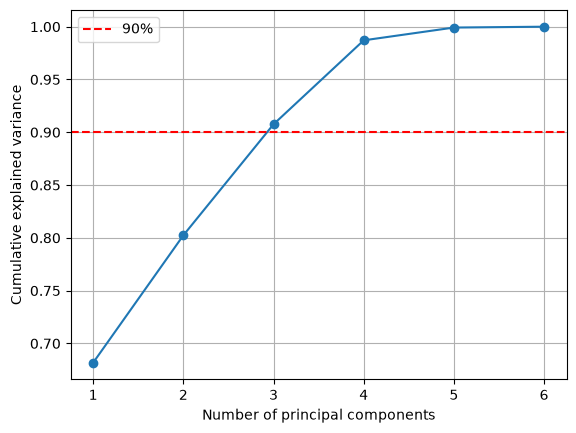

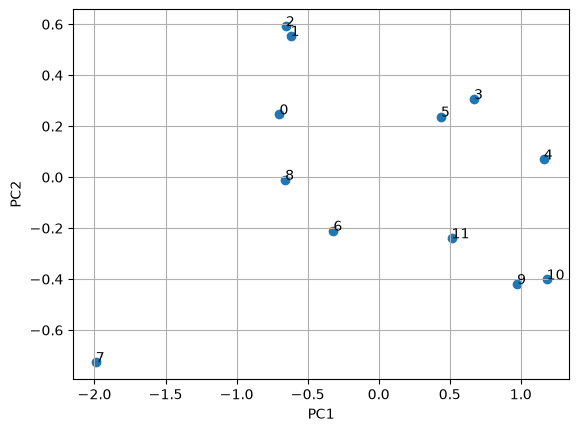

문제 2 TODO를 완성한 뒤 표와 그래프를 출력하세요.


In [109]:
from bisect import bisect_left


print(f"document_embedding: {document_embeddings.shape}")

embedding_mean = np.mean(document_embeddings, axis=0, keepdims=True)          # TODO
centered_embeddings = document_embeddings - embedding_mean     # TODO
covariance = np.cov(centered_embeddings, rowvar=False, ddof=1)              # TODO
print(f"covariance.shape: {covariance.shape}")
eigenvalues, eigenvectors = np.linalg.eigh(covariance)
order = np.argsort(eigenvalues)[::-1]
eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]

explained_ratio = eigenvalues / np.sum(eigenvalues)         # TODO
print(f"explained_ratio.sum(): {explained_ratio.sum()}")

cumulative_ratio = np.cumsum(explained_ratio)        # TODO
print(f"cumulative_ratio: {cumulative_ratio}")

k_90 = bisect_left(cumulative_ratio, 0.9) + 1                  # TODO
print(f"k_90: {k_90}")

components = eigenvectors[:, :k_90]              # TODO
print(f"components: {components}")

projected_embeddings = centered_embeddings @ components    # TODO
reconstructed_pca = projected_embeddings @ components.T + embedding_mean       # TODO
print(f"reconstructed_pca.shape: {reconstructed_pca.shape}")


pca_reconstruction_mse = np.mean((document_embeddings - reconstructed_pca) ** 2)  # TODO
print(f"pca_reconstruction_mse: {pca_reconstruction_mse}")

# "component", "eigenvalue", "explained_ratio", "cumulative_ratio"
pca_table = pd.DataFrame({
    "component": [1, 2, 3, 4, 5, 6],
    "eigenvalue": eigenvalues,
    "explained_ratio": explained_ratio,
    "cumulative_ratio": cumulative_ratio,
})

plt.figure()
plt.plot(
    pca_table["component"],
    cumulative_ratio,
    marker="o"
)
plt.axhline(0.9, color="red", linestyle="--", label="90%")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.xticks(pca_table["component"])
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.scatter(
    projected_embeddings[:, 0],
    projected_embeddings[:, 1],
)

for i in range(len(document_titles)):
    plt.annotate(
        str(i),
        (projected_embeddings[i, 0], projected_embeddings[i, 1]),
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

if document_embeddings is None:
    print("문제 1을 먼저 완성하세요.")
else:
    print("문제 2 TODO를 완성한 뒤 표와 그래프를 출력하세요.")


In [110]:
problem_2_values = {
    "embedding_mean": embedding_mean,
    "centered_embeddings": centered_embeddings,
    "covariance": covariance,
    "eigenvalues": eigenvalues,
    "eigenvectors": eigenvectors,
    "explained_ratio": explained_ratio,
    "cumulative_ratio": cumulative_ratio,
    "k_90": k_90,
    "components": components,
    "projected_embeddings": projected_embeddings,
    "reconstructed_pca": reconstructed_pca,
    "pca_reconstruction_mse": pca_reconstruction_mse,
    "pca_table": pca_table,
}

missing_problem_2 = [name for name, value in problem_2_values.items() if value is None]

if missing_problem_2:
    print("문제 2 미완성:", missing_problem_2)
else:
    assert embedding_mean.shape == (1, 6), "평균 Shape을 확인하세요."
    assert centered_embeddings.shape == (12, 6), "중심화 Shape을 확인하세요."
    assert np.allclose(centered_embeddings.mean(axis=0), 0.0, atol=1e-12), "열별 평균 중심화를 확인하세요."
    assert covariance.shape == (6, 6) and np.allclose(covariance, covariance.T), "공분산 Shape과 대칭성을 확인하세요."
    assert np.all(np.diff(eigenvalues) <= 1e-12), "고유값 내림차순 정렬을 확인하세요."
    assert np.allclose(eigenvectors.T @ eigenvectors, np.eye(6), atol=1e-10), "고유벡터 직교성을 확인하세요."
    assert np.allclose(explained_ratio.sum(), 1.0), "설명분산비 합을 확인하세요."
    assert 1 <= int(k_90) <= 6, "k_90 범위를 확인하세요."
    assert cumulative_ratio[int(k_90) - 1] >= 0.90, "90% 기준을 만족하는지 확인하세요."
    if int(k_90) > 1:
        assert cumulative_ratio[int(k_90) - 2] < 0.90, "최소 차원을 선택했는지 확인하세요."
    assert projected_embeddings.shape == (12, int(k_90)), "PCA 투영 Shape을 확인하세요."
    assert reconstructed_pca.shape == (12, 6), "PCA 복원 Shape을 확인하세요."
    assert list(pca_table.columns) == ["component", "eigenvalue", "explained_ratio", "cumulative_ratio"], "PCA 표의 열을 확인하세요."
    assert result_signature(eigenvalues) == "718a95b1ea77fe7d0113a0e25a84275064309d0dfdfdcfdf326f0b797f523d65", "공분산·eigh·정렬 과정을 확인하세요."
    assert result_signature(cumulative_ratio) == "c6551be64fdd9a6f02ef198178db96afb3b30c424bb02bc498bf38b51e961ac6", "설명분산 계산을 확인하세요."
    assert result_signature([k_90, pca_reconstruction_mse]) == "27e1d0e0250fb6cf9a8234abdf91aa055122017ec8e58f30ddacb36f432b7533", "k_90·투영·복원·MSE를 확인하세요."
    print("문제 2 자동 검증: PASS")


문제 2 자동 검증: PASS


### 문제 2 — PCA 차원 축소 의사결정 메모

1. 평균 중심화가 필요한 이유: 평균을 원점으로 삼아, 데이터가 평균 주변에서 어느 방향으로 퍼지는지 분석하기 위해서
   
2. 가장 큰 고유값 방향이 PC1인 이유: PCA는 분산이 가장 큰 방향을 첫 주성분으로 선택하고, 그 방향을 앞에 배치하도록 정렬하기 때문

3. 원래 차원 / 추천 차원 `k_90`: 6 / 3

4. 누적 설명분산: 0.907571

5. 재구성 MSE: 0.019578365914448843

6. 추천 이유와 주의할 정보 손실: 
    누적 설명분산 90% 이상을 최소 만족하는 차원 개수가 3차원이기 때문에 추천하고, 해당 차원을 제외한 나머지 차원에 대해서는 복원이 되지 않는다.


## 🚀 문제 2 선택 심화 M2 — 공식 점수에 영향 없음

scikit-learn PCA와 직접 구현한 PCA의 설명분산비와 복원 MSE를 비교하세요.

In [111]:
RUN_M2_CHALLENGE = True

if RUN_M2_CHALLENGE:
    from sklearn.decomposition import PCA

    sklearn_pca = PCA(k_90, svd_solver="full")              # TODO: PCA(n_components=k_90, svd_solver="full")
    sklearn_projected = sklearn_pca.fit_transform(document_embeddings)        # TODO
    sklearn_reconstructed = sklearn_pca.inverse_transform(sklearn_projected)    # TODO
    sklearn_mse = np.mean((document_embeddings - sklearn_reconstructed) ** 2)              # TODO
    print(f"sklearn_mse: {sklearn_mse}")
    print(f"pca_reconstruction_mse: {pca_reconstruction_mse}")


    challenge_values = {
        "sklearn_pca": sklearn_pca,
        "sklearn_projected": sklearn_projected,
        "sklearn_reconstructed": sklearn_reconstructed,
        "sklearn_mse": sklearn_mse,
    }
    missing = [name for name, value in challenge_values.items() if value is None]
    if missing:
        print("M2 미완성:", missing)
    else:
        assert np.allclose(explained_ratio[:k_90], sklearn_pca.explained_variance_ratio_), "설명분산비를 비교하세요."
        assert np.allclose(pca_reconstruction_mse, sklearn_mse), "복원 MSE를 비교하세요."
        print("M2 도전 검증: PASS")

else:
    print("M2 도전: SKIPPED")


sklearn_mse: 0.019578365914448843
pca_reconstruction_mse: 0.019578365914448843
M2 도전 검증: PASS


# 문제 3. SVD 저랭크 압축 — 공식 구현 성취도 5점

> **공식 구현 평가 항목:** SVD를 구현하여 행렬을 저차원으로 근사하고, 압축률과 정보 손실 간의 관계를 비교·해석할 수 있다.

## 채점 기준

| 점수 | 기준 |
|---:|---|
| 5점 | 정확한 저랭크 근사 + 압축률-손실 관계 비교·해석 + rank별 실험과 정량 근거 제시 |
| 4점 | SVD 저랭크 근사와 압축률·정보 손실 비교·해석 완료 |
| 3점 | 근사는 되나 압축률-손실 분석 또는 해석이 부족 |
| 2점 | 분해·근사 오류로 복원 결과가 잘못됨 |
| 1점 | SVD 구현이 되지 않음 |

## 실무 배경

저장팀은 중심화된 임베딩 행렬을 저랭크 형태로 압축하려고 합니다. 요구 조건은 **에너지 90% 이상**과 **원본보다 적은 저장 원소 수**입니다. rank별 정보 보존율·오차·저장량을 비교하고 추천 rank를 보고하세요.

## 필수 구현

1. `np.linalg.svd(centered_embeddings, full_matrices=False)`로 Compact SVD를 수행하세요.
2. 특이값 **제곱**으로 에너지 비율과 누적 에너지를 계산하세요.
3. 90% 이상을 처음 만족하는 최소 `r_90`을 구하세요.
4. rank 1·2·3 각각에 대해 복원, 에너지, MSE, 상대 Frobenius 오차를 계산하세요.
5. 저랭크 저장 원소 수는 `m*r + r + r*n`으로 계산하세요.
6. 원본 `m*n` 대비 저장 절감률을 비교표와 그래프로 정리하세요.

> `Σ_r`는 `np.diag(singular_values[:rank])`로 만든 대각행렬입니다.


singular_energy_ratio: [0.681743 0.120643 0.105185 0.07951  0.012105 0.000814]
cumulative_energy: [0.681743 0.802387 0.907571 0.987082 0.999186 1.      ]
original_storage: 72


,rank,retained_energy,mse,relative_frobenius_error,stored_values,storage_reduction
0,1,0.681743,0.067414,0.564143,19,0.736111
1,2,0.802387,0.041859,0.444537,38,0.472222
2,3,0.907571,0.019578,0.304021,57,0.208333


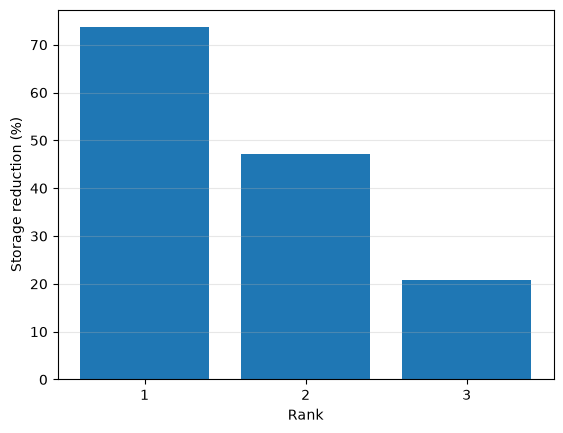

문제 3 TODO를 완성한 뒤 표와 그래프를 출력하세요.


In [112]:
U, singular_values, Vt = np.linalg.svd(centered_embeddings, full_matrices=False)
# print(f"U, singular_values, Vt: {U, singular_values, Vt}")

singular_energy_ratio = singular_values**2 / np.sum(singular_values**2)
cumulative_energy = np.cumsum(singular_energy_ratio)

print(f"singular_energy_ratio: {singular_energy_ratio}")
print(f"cumulative_energy: {cumulative_energy}")

r_90 = bisect_left(cumulative_energy, 0.9) + 1                      # TODO
original_storage = centered_embeddings.size
print(f"original_storage: {original_storage}")
svd_reconstructions = {}

for rank in range(1, 4):
    reconstructed_centered = (U[:, :rank] @ np.diag(singular_values[:rank]) @ Vt[:rank, :])
    svd_reconstructions[rank] = reconstructed_centered + embedding_mean

reconstructed_svd_r90 = svd_reconstructions[r_90]     # TODO
svd_r90_mse = np.mean((document_embeddings - reconstructed_svd_r90) ** 2)

# 원본 행, 열 수
m, n = centered_embeddings.shape
rows = []

# 남긴 SVD 성분 개수, 해당 개수로 복원하고 ㅍ평균까지 더한 문서 행렬
for rank, restored in svd_reconstructions.items():
    # 원본 - 복원값
    error = document_embeddings - restored
    # 복원용 SVD 부품을 저장할 숫자 개수
    stored_values = m * rank + rank + rank * n

    rows.append({
        "rank": rank,
        "retained_energy": cumulative_energy[rank - 1],
        "mse": np.mean(error**2),
        "relative_frobenius_error": (
            np.linalg.norm(error, ord="fro")
            / np.linalg.norm(centered_embeddings, ord="fro")
        ),
        "stored_values": stored_values,
        "storage_reduction": (
            original_storage - stored_values
        ) / original_storage
    })

svd_table = pd.DataFrame(rows)
display(svd_table)

plt.figure()
plt.bar(
    svd_table["rank"],
    svd_table["storage_reduction"] * 100,
)
plt.xlabel("Rank")
plt.ylabel("Storage reduction (%)")
plt.xticks(svd_table["rank"])
plt.grid(axis="y", alpha=0.3)
plt.show()

if centered_embeddings is None:
    print("문제 2를 먼저 완성하세요.")
else:
    print("문제 3 TODO를 완성한 뒤 표와 그래프를 출력하세요.")


In [113]:
problem_3_values = {
    "U": U,
    "singular_values": singular_values,
    "Vt": Vt,
    "singular_energy_ratio": singular_energy_ratio,
    "cumulative_energy": cumulative_energy,
    "r_90": r_90,
    "original_storage": original_storage,
    "svd_table": svd_table,
    "svd_reconstructions": svd_reconstructions,
    "reconstructed_svd_r90": reconstructed_svd_r90,
    "svd_r90_mse": svd_r90_mse,
}

missing_problem_3 = [name for name, value in problem_3_values.items() if value is None]

if missing_problem_3:
    print("문제 3 미완성:", missing_problem_3)
else:
    assert U.shape == (12, 6), "U Shape을 확인하세요."
    assert singular_values.shape == (6,), "특이값 Shape을 확인하세요."
    assert Vt.shape == (6, 6), "Vt Shape을 확인하세요."
    assert np.all(np.diff(singular_values) <= 1e-12), "특이값 순서를 확인하세요."
    assert np.allclose(singular_energy_ratio.sum(), 1.0), "특이값 제곱 기반 에너지 비율을 확인하세요."
    assert 1 <= int(r_90) <= 6, "r_90 범위를 확인하세요."
    assert cumulative_energy[int(r_90) - 1] >= 0.90, "90% 에너지 기준을 확인하세요."
    if int(r_90) > 1:
        assert cumulative_energy[int(r_90) - 2] < 0.90, "최소 rank를 선택했는지 확인하세요."
    assert original_storage == 72, "원본 저장 원소 수 m*n을 확인하세요."
    assert reconstructed_svd_r90.shape == (12, 6), "SVD 복원 Shape을 확인하세요."
    assert np.allclose(svd_r90_mse, pca_reconstruction_mse), "같은 rank의 PCA·SVD 복원 관계를 확인하세요."
    expected_columns = ["rank", "retained_energy", "mse", "relative_frobenius_error", "stored_values", "storage_reduction"]
    assert list(svd_table.columns) == expected_columns, "SVD 비교표의 열을 확인하세요."
    assert np.all(np.diff(svd_table["retained_energy"]) > 0), "rank별 에너지가 증가해야 합니다."
    assert np.all(np.diff(svd_table["mse"]) < 0), "rank별 MSE가 감소해야 합니다."
    assert result_signature(singular_values) == "ac3b993576e14ee558a5c36f37c5b70498d8bcdfac55347c84747590754028f7", "Compact SVD 결과를 확인하세요."
    assert result_signature(svd_table[expected_columns].to_numpy()) == "d6ee23661d420d4dc2eb9afd86330f6d5902354bbaab10c718a7beb4515b2416", "rank별 복원·오차·저장량 계산을 확인하세요."
    assert result_signature([r_90, svd_r90_mse]) == "27e1d0e0250fb6cf9a8234abdf91aa055122017ec8e58f30ddacb36f432b7533", "r_90과 복원 MSE를 확인하세요."
    print("문제 3 자동 검증: PASS")


문제 3 자동 검증: PASS


### 문제 3 — SVD 압축 의사결정 메모

1. rank 증가에 따른 에너지와 오차 변화: 
   오차: 0.067414 > 0.041859 > 0.019578
   에너지: 0.681743 > 0.802387 > 0.907571
2. 원본 저장 원소 수: 72
3. 추천 rank `r_90`: 3
4. 에너지 보존율: 90.7571%
5. 저장 원소 수 / 저장 절감률: 57 / 20.83333%
6. 재구성 MSE: 0.019578
7. 추천 이유와 한계:
    요구 조건인 에너지 90%이상을 맞추면서 원본보다 적은 저장 원소 수의 최소값을 만족하는 rank가 3이므로.

## 🚀 문제 3 선택 심화 M3 — 공식 점수에 영향 없음

같은 rank에서 직접 구현 PCA 복원과 SVD 복원이 거의 같은지 확인하세요.

In [114]:
RUN_M3_CHALLENGE = True

if RUN_M3_CHALLENGE:
    pca_vs_svd_max_abs_diff = np.max(
        np.abs(reconstructed_pca - reconstructed_svd_r90)
    )  # TODO: 두 복원 행렬의 최대 절대 차이
    reconstructions_match = np.allclose(
        reconstructed_pca, reconstructed_svd_r90, atol=1e-10
    )    # TODO: np.allclose(..., atol=1e-10)

    if pca_vs_svd_max_abs_diff is None or reconstructions_match is None:
        print("M3 미완성: 두 복원 결과를 비교하세요.")
    else:
        print("PCA-SVD 복원 최대 절대 차이:", pca_vs_svd_max_abs_diff)
        assert bool(reconstructions_match), "같은 rank의 PCA·SVD 복원 결과를 확인하세요."
        assert pca_vs_svd_max_abs_diff < 1e-10
        print("M3 도전 검증: PASS")
else:
    print("M3 도전: SKIPPED")


PCA-SVD 복원 최대 절대 차이: 1.1657341758564144e-15
M3 도전 검증: PASS


# 문제 4. Causal Attention과 출력 Projection 학습 — 추가 종합 평가 5점

> 문제 4는 공식 구현 성취도 15점과 분리된 **6~7장 추가 종합 평가**입니다.

## 추가 종합 평가 기준

| 점수 | 기준 |
|---:|---|
| 5점 | Checkpoint A·B·C 정확히 구현, 모든 검증 통과, 누수·NLL·Gradient·Loss 변화를 근거로 정확히 해석 |
| 4점 | Attention·CE·Autograd 업데이트 구현과 핵심 검증 완료, 일부 해석 근거 부족 |
| 3점 | Attention·CE는 대체로 구현했으나 Autograd 업데이트 또는 검증이 불완전 |
| 2점 | 일부 계산은 수행했으나 Mask·Softmax 축·Shape·Gradient 중 주요 오류 존재 |
| 1점 | 코드 작성을 시작했으나 핵심 흐름이 구현되지 않음 |
| 0점 | 미제출 또는 전체 실행 불가 |

아래 고정 토큰 시퀀스로 Attention Forward와 다음 토큰 Cross Entropy를 계산합니다.

```text
<BOS> → 사내 → 비밀번호 → 재설정 → 방법
```

기본 문제에서는 Q/K/V Projection을 고정하고 출력 Projection `W_out`, `b_out`만 한 번 학습합니다. 문제를 한 번에 작성하지 말고 세 Checkpoint로 나누어 진행하세요.

| Checkpoint | 구현 범위 | 완료 조건 |
|---|---|---|
| A | Q/K/V → Context | Shape 정상, 행별 합 1, 미래 Weight 0 |
| B | Vocabulary Logits → CE | 확률 행별 합 1, 유한한 위치별 NLL |
| C | Autograd → SGD 1회 | Gradient Shape 정상, 업데이트 후 Loss 감소 |

> `F.cross_entropy`에는 Softmax 확률이 아니라 원본 logits를 전달해야 합니다.


In [115]:
vocabulary = ["<BOS>", "사내", "비밀번호", "재설정", "방법", "안내", "<EOS>"]
input_tokens = ["<BOS>", "사내", "비밀번호", "재설정", "방법"]

token_embeddings = np.array([
    [0.6, 0.1, 0.0, 0.2],
    [0.7, 0.2, 0.1, 0.1],
    [0.9, 0.0, 0.3, 0.2],
    [0.8, 0.1, 0.5, 0.4],
    [0.5, 0.3, 0.6, 0.7],
], dtype=np.float64)

W_Q = np.array([
    [ 0.5, -0.2,  0.3],
    [ 0.1,  0.4, -0.1],
    [ 0.3,  0.2,  0.5],
    [-0.2,  0.3,  0.4],
], dtype=np.float64)

W_K = np.array([
    [ 0.4,  0.1, -0.2],
    [-0.1,  0.5,  0.2],
    [ 0.2, -0.3,  0.6],
    [ 0.3,  0.2,  0.4],
], dtype=np.float64)

W_V = np.array([
    [ 0.3,  0.2,  0.4],
    [ 0.4, -0.1,  0.2],
    [-0.2,  0.5,  0.3],
    [ 0.1,  0.4, -0.3],
], dtype=np.float64)

initial_W_out = np.array([
    [ 0.2, -0.1,  0.3,  0.0, -0.2,  0.1,  0.05],
    [-0.3,  0.4, -0.1,  0.2,  0.1, -0.2,  0.30],
    [ 0.1,  0.0,  0.2, -0.2,  0.4,  0.3, -0.10],
], dtype=np.float64)

initial_b_out = np.array([0.0, 0.1, -0.05, 0.0, 0.05, -0.1, 0.0], dtype=np.float64)

# 각 위치에서 예측해야 하는 다음 토큰 index입니다.
targets = np.array([1, 2, 3, 4, 6], dtype=np.int64)

print("token_embeddings shape:", token_embeddings.shape)
print("W_Q/W_K/W_V shape:", W_Q.shape, W_K.shape, W_V.shape)
print("initial_W_out shape:", initial_W_out.shape)
print("targets:", targets)


token_embeddings shape: (5, 4)
W_Q/W_K/W_V shape: (4, 3) (4, 3) (4, 3)
initial_W_out shape: (3, 7)
targets: [1 2 3 4 6]


## Checkpoint A. Attention Forward

1. `Q`, `K`, `V`를 만들고 `QKᵀ / √d_k`를 계산하세요.
2. `j > i`인 미래 위치를 Boolean Causal Mask로 가리세요.
3. Mask를 **Softmax 전에** 적용하세요.
4. 마지막 축에서 안정 Softmax를 계산하세요.
5. `context = attention_weights @ V`를 만드세요.
6. 아래 검증 셀에서 `Checkpoint A: PASS`를 확인하세요.


In [116]:

def stable_softmax(values, axis=-1):
    """수치적으로 안정적인 Softmax를 완성하세요."""
    # TODO
    shifted = values - np.max(values, axis=axis, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / np.sum(exp_values, axis=axis, keepdims=True)


Q = token_embeddings @ W_Q                # TODO: token_embeddings @ W_Q
K = token_embeddings @ W_K                # TODO
V = token_embeddings @ W_V                # TODO
d_k = K.shape[-1]              # TODO
attention_scores = Q @ K.T / np.sqrt(d_k) # TODO: Q @ K.T / sqrt(d_k)
causal_mask = np.triu(
    np.ones_like(
        attention_scores, dtype=bool
    ), k=1
)
print(f"causal_mask: {causal_mask}")
masked_scores = np.where(
    causal_mask, -np.inf, attention_scores
)    # TODO
print(f"masked_scores: {masked_scores}")
attention_weights = stable_softmax(masked_scores, axis=-1)
print(f"attention_weights: {attention_weights}")

context = attention_weights @ V          # TODO
print(f"context: {context}")

print("Checkpoint A TODO를 완성하세요.")


causal_mask: [[False  True  True  True  True]
 [False False  True  True  True]
 [False False False  True  True]
 [False False False False  True]
 [False False False False False]]
masked_scores: [[0.040588     -inf     -inf     -inf     -inf]
 [0.059525 0.067088     -inf     -inf     -inf]
 [0.072746 0.083947 0.160272     -inf     -inf]
 [0.081637 0.095147 0.164891 0.268583     -inf]
 [0.075806 0.089605 0.129096 0.239369 0.367195]]
attention_weights: [[1.       0.       0.       0.       0.      ]
 [0.498109 0.501891 0.       0.       0.      ]
 [0.322296 0.325927 0.351777 0.       0.      ]
 [0.232235 0.235394 0.252397 0.279974 0.      ]
 [0.179063 0.181551 0.188864 0.210883 0.239638]]
context: [[0.24     0.19     0.2     ]
 [0.260076 0.200038 0.260227]
 [0.249519 0.273909 0.305949]
 [0.241292 0.353826 0.323798]
 [0.236363 0.423441 0.30071 ]]
Checkpoint A TODO를 완성하세요.


In [117]:

checkpoint_a = {
    "Q": Q,
    "K": K,
    "V": V,
    "d_k": d_k,
    "attention_scores": attention_scores,
    "causal_mask": causal_mask,
    "masked_scores": masked_scores,
    "attention_weights": attention_weights,
    "context": context,
}
missing_a = [name for name, value in checkpoint_a.items() if value is None]

if missing_a:
    print("Checkpoint A 미완성:", missing_a)
else:
    assert Q.shape == K.shape == V.shape == (5, 3)
    assert int(d_k) == 3
    assert attention_scores.shape == causal_mask.shape == masked_scores.shape == (5, 5)
    assert causal_mask.dtype == bool
    assert attention_weights.shape == (5, 5)
    assert np.allclose(attention_weights.sum(axis=-1), 1.0)
    assert np.allclose(attention_weights[np.triu_indices(5, k=1)], 0.0, atol=1e-8)
    assert context.shape == (5, 3)
    assert result_signature(attention_weights) == "44b7fab0c5c307a628df153481124b6e3a252271159aae8fd61733d88d0f5b68"
    print("Checkpoint A: PASS")


Checkpoint A: PASS


## Checkpoint B. Vocabulary Softmax와 위치별 Loss

1. `context @ initial_W_out + initial_b_out`로 raw logits를 만드세요.
2. 마지막 축에서 Vocabulary Softmax를 계산하세요.
3. 각 위치의 정답 다음 토큰 확률과 NLL을 계산하세요.
4. 평균 NLL을 NumPy Cross Entropy로 저장하세요.
5. 가장 큰 NLL 위치를 확인하세요.
6. 검증 셀에서 `Checkpoint B: PASS`를 확인하세요.


In [118]:

initial_vocab_logits_np = context @ initial_W_out + initial_b_out  # TODO
initial_vocab_probs_np = stable_softmax(
    initial_vocab_logits_np, axis=-1
)

print(f"initial_vocab_probs_np: {initial_vocab_probs_np}")

correct_token_probs = initial_vocab_probs_np[
    np.arange(len(targets)), targets
]

print(f"correct_token_probs: {correct_token_probs}")

position_nll = -np.log(correct_token_probs)
print(f"position_nll: {position_nll}")

numpy_cross_entropy = np.mean(position_nll)
worst_nll_position = np.argmax(position_nll)
print(f"worst_nll_position: {worst_nll_position}")

if context is None:
    print("Checkpoint A를 먼저 완성하세요.")
else:
    print("Checkpoint B TODO를 완성하세요.")


initial_vocab_probs_np: [[0.138102 0.159015 0.142593 0.136319 0.151108 0.129411 0.143451]
 [0.138017 0.15812  0.143942 0.133929 0.153152 0.130767 0.142073]
 [0.134083 0.161539 0.142421 0.13345  0.156022 0.129294 0.143192]
 [0.129984 0.165724 0.140427 0.134146 0.157522 0.126903 0.145293]
 [0.12652  0.170005 0.138213 0.13627  0.156874 0.123872 0.148245]]
correct_token_probs: [0.159015 0.143942 0.13345  0.157522 0.148245]
position_nll: [1.838759 1.938342 2.014031 1.848189 1.908886]
worst_nll_position: 2
Checkpoint B TODO를 완성하세요.


In [119]:

checkpoint_b = {
    "initial_vocab_logits_np": initial_vocab_logits_np,
    "initial_vocab_probs_np": initial_vocab_probs_np,
    "correct_token_probs": correct_token_probs,
    "position_nll": position_nll,
    "numpy_cross_entropy": numpy_cross_entropy,
    "worst_nll_position": worst_nll_position,
}
missing_b = [name for name, value in checkpoint_b.items() if value is None]

if missing_b:
    print("Checkpoint B 미완성:", missing_b)
else:
    assert initial_vocab_logits_np.shape == initial_vocab_probs_np.shape == (5, 7)
    assert np.allclose(initial_vocab_probs_np.sum(axis=-1), 1.0)
    assert correct_token_probs.shape == position_nll.shape == (5,)
    assert np.isfinite(position_nll).all() and np.isfinite(numpy_cross_entropy)
    assert int(worst_nll_position) == int(np.argmax(position_nll))
    assert result_signature(initial_vocab_probs_np) == "488e23c3dcc0de21ef16a8bc79192798e7663b9bb5c9766bed65014e016980bc"
    print("Checkpoint B: PASS")


Checkpoint B: PASS


## Checkpoint C. PyTorch Autograd와 한 번의 SGD 업데이트

1. `context`, targets, `W_out`, `b_out`을 `torch.float64`로 준비하세요.
2. `W_out`, `b_out`만 `requires_grad=True`로 만드세요.
3. `torch.optim.SGD([W_out_t, b_out_t], lr=1.0)`을 사용하세요.
4. `zero_grad → forward → loss → backward → Gradient 복사 → step` 순서로 실행하세요.
5. `step()` 뒤에는 새 Forward로 Loss를 다시 계산하세요.
6. 검증 셀에서 `Checkpoint C: PASS`를 확인하세요.


In [120]:

context_t = torch.tensor(context, dtype=torch.float64)
targets_t = torch.tensor(targets, dtype=torch.long)
W_out_t = torch.tensor(initial_W_out, dtype=torch.float64, requires_grad=True)
b_out_t = torch.tensor(initial_b_out, dtype=torch.float64, requires_grad=True)
optimizer = torch.optim.SGD([W_out_t, b_out_t], lr=1.0)
optimizer.zero_grad()

initial_logits_t = context_t @ W_out_t + b_out_t
initial_loss_t = F.cross_entropy(initial_logits_t, targets_t)
initial_loss_t.backward()

assert W_out_t.grad is not None
assert b_out_t.grad is not None

grad_W_autograd = W_out_t.grad.detach().clone()
grad_b_autograd = b_out_t.grad.detach().clone()

print(f"grad_W_autograd: {grad_W_autograd.shape}")
print(f"grad_b_autograd: {grad_b_autograd.shape}")

initial_probs_torch = torch.softmax(initial_logits_t, dim=-1)
print(f"initial_probs_torch: {initial_probs_torch.shape}")

optimizer.step()

with torch.no_grad():
    updated_logits_t = context_t @ W_out_t + b_out_t
    updated_loss_t = F.cross_entropy(updated_logits_t, targets_t)

initial_torch_loss = initial_loss_t.item()
updated_torch_loss = updated_loss_t.item()

print(f"initial_torch_loss: {initial_torch_loss}")
print(f"updated_torch_loss: {updated_torch_loss}")

if context is None or numpy_cross_entropy is None:
    print("Checkpoint A와 B를 먼저 완성하세요.")
else:
    print("Checkpoint C TODO를 완성하세요.")


grad_W_autograd: torch.Size([3, 7])
grad_b_autograd: torch.Size([7])
initial_probs_torch: torch.Size([5, 7])
initial_torch_loss: 1.9096416144216348
updated_torch_loss: 1.853165050440118
Checkpoint C TODO를 완성하세요.


In [121]:

checkpoint_c = {
    "optimizer": optimizer,
    "grad_W_autograd": grad_W_autograd,
    "grad_b_autograd": grad_b_autograd,
    "initial_probs_torch": initial_probs_torch,
    "initial_torch_loss": initial_torch_loss,
    "updated_torch_loss": updated_torch_loss,
}
missing_c = [name for name, value in checkpoint_c.items() if value is None]

if missing_c:
    print("Checkpoint C 미완성:", missing_c)
else:
    assert np.allclose(numpy_cross_entropy, initial_torch_loss)
    assert grad_W_autograd.shape == (3, 7)
    assert grad_b_autograd.shape == (7,)
    assert updated_torch_loss < initial_torch_loss
    assert result_signature([numpy_cross_entropy, initial_torch_loss, updated_torch_loss]) == "b8368a6bdafae26a087cdeec0d49cbf1c9e5e0278c47a63c6b7d7a0671b9a5b7"
    assert result_signature(grad_W_autograd) == "4c50d7b9a7ead967ffe8ebe1bb6f9c07ffc496b7223a5128c61438ed55e741b5"
    assert result_signature(grad_b_autograd) == "26944bff87ae878f1f2a34240dc8ba6188226caeaca124397cf1286681462e64"
    print("Checkpoint C: PASS")


Checkpoint C: PASS


### 문제 4 — Attention·학습 진단 보고

1. Attention Score 행과 열의 의미:
   행은 각 정보를 모으려는 토큰별로 나눈 것이고
   열은 다른 토큰과의 관계, 다른 토큰 위치를 나타낸 것이다.

2. Causal Mask를 Softmax 전에 적용하는 이유:
    미래 위치의 점수를 -inf로 바꿔서 그 위치의 비중을 softmax 처리해서 0으로 만들고, 행별 최댓값을 빼서 지수 함수 계산에서 너무 큰 수가 생기는 것을 방지하기 위해서

3. 미래 토큰 누수 여부 / 행별 합: X / 1

4. 가장 큰 NLL 위치와 토큰: 2, "재설정"

5. NumPy CE / PyTorch 초기 Loss: 둘 다 1.9096416144216348

6. 업데이트 전 Loss / 업데이트 후 Loss: 1.9096416144216348 / 1.853165050440118

7. `backward()`와 `step()`의 역할 차이: 
    backward는 역전파 과정을 통해서 grad를 계산하고,
    step은 계산된 grad로 파라미터를 업데이트 한다.

8. Gradient 계산과 업데이트가 정상이라고 판단한 근거:
    loss가 업데이트 후 더 줄었고, 각 출력 파라미터의 shape가 기존 파라미터 shape와 일치했기 때문이다.


## 🚀 문제 4 선택 심화 M4 — 추가 종합 점수에 영향 없음

Autograd가 계산한 출력 Projection Gradient를 NumPy로 직접 계산해 비교하세요.

```text
dLogits = (P - Y_one_hot) / N
dW_out = contextᵀ @ dLogits
db_out = sum(dLogits, axis=0)
```

In [122]:
RUN_M4_CHALLENGE = True

if RUN_M4_CHALLENGE:
    one_hot_targets = np.zeros(initial_vocab_probs_np.shape)
    one_hot_targets[np.arange(len(targets)), targets] = 1
    print(f"one_hot_targets: {one_hot_targets}")

    dlogits_manual = (initial_vocab_probs_np - one_hot_targets) / len(initial_vocab_probs_np)   # TODO: (P - Y_one_hot) / N
    dW_out_manual = context.T @ dlogits_manual    # TODO: context.T @ dlogits_manual
    db_out_manual = dlogits_manual.sum(axis=0)    # TODO: dlogits_manual.sum(axis=0)

    challenge_values = {
        "one_hot_targets": one_hot_targets,
        "dlogits_manual": dlogits_manual,
        "dW_out_manual": dW_out_manual,
        "db_out_manual": db_out_manual,
    }
    missing = [name for name, value in challenge_values.items() if value is None]
    if missing:
        print("M4 미완성:", missing)
    else:
        assert np.allclose(dW_out_manual, grad_W_autograd, atol=1e-12), "수동 dW와 Autograd를 비교하세요."
        assert np.allclose(db_out_manual, grad_b_autograd, atol=1e-12), "수동 db와 Autograd를 비교하세요."
        print("M4 도전 검증: PASS")
else:
    print("M4 도전: SKIPPED")


one_hot_targets: [[0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1.]]
M4 도전 검증: PASS


# 🧾 최종 엔지니어링 요약 보고서

아래 항목을 실제 실행 결과로 완성하세요. 숫자·문서명·Shape을 근거로 작성하세요.

## 1. 문서 검색
- Query: "비밀번호를 잊었을 때 계정을 다시 사용하는 방법"
- Cosine Top-3:
  - "계정 잠금 해제 가이드"
  - "비밀번호 재설정 절차"
  - "VPN 접속 오류 해결"
- 검색 결과 평가:
    VPN 접속 오류 해결은 기존 질문(Query)에 대한 답변으로 올바르지 않았다.

## 2. PCA 차원 축소
- 추천 차원 `k`: 3
- 누적 설명분산: 0.907571
- 재구성 MSE: 0.019578365914448843

## 3. SVD 압축
- 추천 rank `r`: 3
- 에너지 보존율: 0.907571
- 저장 절감률: 20.83333%
- 재구성 MSE: 0.019578

## 4. Attention 및 다음 토큰 예측
- 미래 토큰 누수 여부: X
- 평균 Cross Entropy: 1.9096416144216348
- 가장 큰 NLL 위치: 2

## 5. 학습 업데이트
- 업데이트 전 Loss: 1.9096416144216348
- 업데이트 후 Loss: 1.853165050440118
- 감소 여부: 감소했음

## 6. 최종 결론
- 이번 PoC(proof of concept)에서 확인한 핵심 수학 원리:
  - PCA, SVD에서 주요 방향 또는 성분 3개를 남겨 약 90% 분산 혹은 에너지를 보존했으며, SVD의 경우 저장 원소수를 72 > 57로 줄였다.
  - Causal Mask로 미래 토큰의 Attention 점수를 -inf 치환하여 softmax로 0으로 만들었다.
- 운영 전에 추가로 검증해야 할 항목:
  - 실제 문서와 다양한 질문에서도 관련 문서가 상위에 검색되는지 확인해야 한다.


# 최종 제출 체크

- [x] 공식 성취도 문제 1~3 자동 검증이 모두 `PASS`입니다.
- [x] 추가 종합 평가 문제 4 Checkpoint A·B·C가 모두 `PASS`입니다.
- [x] 그래프와 표가 출력된 상태입니다.
- [x] 문제별 해석과 의사결정 메모를 실제 결과로 작성했습니다.
- [x] 최종 엔지니어링 요약 보고서를 작성했습니다.
- [x] 선택 심화는 점수 필수 조건이 아니며, 수행하지 않았다면 flag가 `False`입니다.
- [x] 새 런타임에서 `모두 실행`이 완료됩니다.

---

Copyright ⓒ TeamSparta All rights reserved.
